In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_HERE = Path.cwd()
_ROOT = _HERE.parent if _HERE.name == "EDA" else _HERE
_EDA  = _ROOT / "EDA"
for _p in (str(_ROOT), str(_EDA)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from config import DATA_DIR, PATHS, PARAMS
from analysis.pipeline import DataAnalysisPipeline
from analysis.gene_bias_rda import compute_gene_wise_bias_rda
from analysis.plot_gene_bias import plot_gene_wise_bias_summary
from viz_style import apply_style
apply_style()

In [3]:
adata = sc.read_h5ad(PATHS["merged_qc"])
adata = adata[adata.obs["QC_Passed"] == True]

combined_metrics = [
    "log(Total Reads)", "Spliced Reads (%)", "gDNA Contamination (Intron/Exon)",
    "rRNA Fraction", "RNA Degradation (3' Bias)", "Platelet Score",
    "GC Bias", "Gene Length Bias", "NG80", "NP80", "(NP80/NG80)",
    "Sample Volume (mL)", "Total Centrifugation Force (g)",
]

In [4]:
# Ibarra et al. is excluded from RDA and bias~phenotype analyses because their
# study design is not a normal-vs-disease comparison: phenotype and batch are
# fully confounded by design, making variance decomposition results uninterpretable.
EXCLUDE_FROM_PHENOTYPE_ANALYSIS = ["Ibarra et al."]

adata_rda = adata[~adata.obs["Author"].isin(EXCLUDE_FROM_PHENOTYPE_ANALYSIS)].copy()
pipeline_rda = DataAnalysisPipeline(
    adata=adata_rda,
    bias_metrics_df=None,
    phenotype_col='Phenotype_Processed',
    batch_col='Batch_ID',
    analysis_metrics=combined_metrics,
    min_samples_per_study=75
)
pipeline_rda.set_layer('CPM_log1p')

--- [Init] Preparing Metadata ---
   Valid studies (>= 75): 9
   [Skip] Too few samples: ['Tuni et al.', 'Reggiardo et al.', 'Raissadati et al.', 'Block et al.', 'Peddu\xa0et al.']


--- Layer: switching to 'CPM_log1p' ---


### Bias ~ Protein Coding Gene Correlation (Healthy Control)

In [5]:
from analysis.gene_bias_rda import compute_gene_wise_bias_rda

hc_metrics = combined_metrics + ["Batch_ID"]
adata_tmp = adata[adata.obs['library_selection'] != 'Whole-Exome Capture'].copy()
adata_tmp = adata_tmp[adata_tmp.obs[hc_metrics].notna().all(axis=1)].copy()
adata_tmp.obs["Batch_ID"] = adata_tmp.obs["Batch_ID"].astype(str)

df_hc_detail, df_hc_summary = compute_gene_wise_bias_rda(
    adata_tmp,
    bias_metrics   = hc_metrics,
    target_labels  = "Healthy Control",
    group_name     = "HC",
    layer          = "CPM_log1p",
    min_expressed_frac = 0.1,
)

df_batch_only, _ = compute_gene_wise_bias_rda(
    adata_tmp,
    bias_metrics   = ["Batch_ID"],
    target_labels  = "Healthy Control",
    group_name     = "HC (batch only)",
    layer          = "CPM_log1p",
    min_expressed_frac = 0.1,
)

df_hc_detail["Joint_R2_Biases_Given_Batch"] = (
    df_hc_detail["Joint_R2_All_Biases"].values - df_batch_only["Joint_R2_All_Biases"].values
).clip(0.0)

print(f"Joint R2 all (biases + batch) : mean={df_hc_detail['Joint_R2_All_Biases'].mean():.4f}, "
      f"genes >10% = {(df_hc_detail['Joint_R2_All_Biases'] > 0.10).sum():,}")
print(f"Joint R2 batch only           : mean={df_batch_only['Joint_R2_All_Biases'].mean():.4f}, "
      f"genes >10% = {(df_batch_only['Joint_R2_All_Biases'] > 0.10).sum():,}")
print(f"Joint R2 biases | batch       : mean={df_hc_detail['Joint_R2_Biases_Given_Batch'].mean():.4f}, "
      f"genes >10% = {(df_hc_detail['Joint_R2_Biases_Given_Batch'] > 0.10).sum():,}")


--- [HC] Vectorized Gene-wise Partial RDA ---


[HC] Valid samples : 693


[HC] Genes analyzed (≥10% expressed) : 16,580
[HC] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9586   0.3518                15234     > 10%
                Unique: log(Total Reads)  0.0588   0.0020                    1      > 5%
               Unique: Spliced Reads (%)  0.0484   0.0021                    0      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.0928   0.0042                   70      > 5%
                   Unique: rRNA Fraction  0.0351   0.0015                    0      > 5%
       Unique: RNA Degradation (3' Bias)  0.1126   0.0030                   19      > 5%
                  Unique: Platelet Score  0.2426   0.0078                  616      > 5%
                         Unique: GC Bias  0.1303   0.0072                  212      > 5%
                Unique: Gene Length Bias  0.0768   0.0062                   57      > 5%
                            Unique: NG80  0.0426   0.0019  

[HC (batch only)] Valid samples : 693


[HC (batch only)] Genes analyzed (≥10% expressed) : 16,580
[HC (batch only)] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
            Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
ALL_BIASES_COMBINED (Joint R²)   0.914   0.1878                11236     > 10%
              Unique: Batch_ID   0.914   0.1878                14245      > 5%


Joint R2 all (biases + batch) : mean=0.3518, genes >10% = 15,234
Joint R2 batch only           : mean=0.1878, genes >10% = 11,236
Joint R2 biases | batch       : mean=0.1640, genes >10% = 11,504


In [6]:
df_hc_summary["Pct_Highly_Biased"] = (df_hc_summary["Genes_Highly_Biased"] / len(df_hc_detail)) * 100

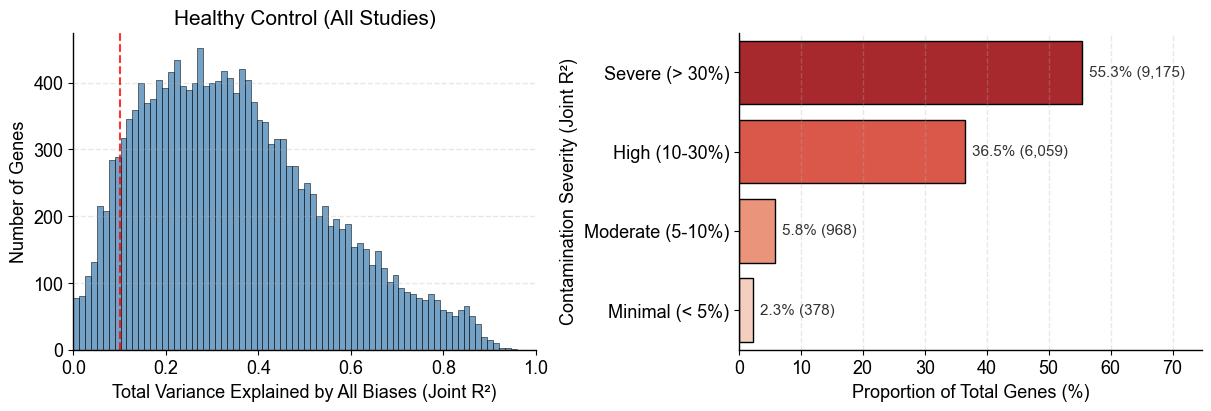

In [7]:
import os
from analysis.plot_gene_bias import plot_gene_wise_bias_summary

os.makedirs("./Analysis_Results/GeneBiasHC", exist_ok=True)
plot_gene_wise_bias_summary(
    df_hc_detail,
    group_name="Healthy Control (All Studies)",
    save_path=None,  # was "./Analysis_Results/GeneBiasHC/gene_wise_bias_rda_summary.png"
)


 > Chalasani et al.  (n=993)

--- [Chalasani et al.] Vectorized Gene-wise Partial RDA ---


[Chalasani et al.] Valid samples : 993


[Chalasani et al.] Genes analyzed (≥10% expressed) : 15,641
[Chalasani et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.8837   0.1266                 6910     > 10%
                Unique: log(Total Reads)  0.0738   0.0044                   19      > 5%
               Unique: Spliced Reads (%)  0.6217   0.0180                 1347      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1115   0.0059                   83      > 5%
                   Unique: rRNA Fraction  0.0518   0.0018                    1      > 5%
       Unique: RNA Degradation (3' Bias)  0.0954   0.0037                   35      > 5%
                  Unique: Platelet Score  0.3614   0.0136                 1052      > 5%
                         Unique: GC Bias  0.0903   0.0040                   51      > 5%
                Unique: Gene Length Bias  0.0738   0.0041                   44      > 5%
                            Unique: NG80  0.0711   0.0029  

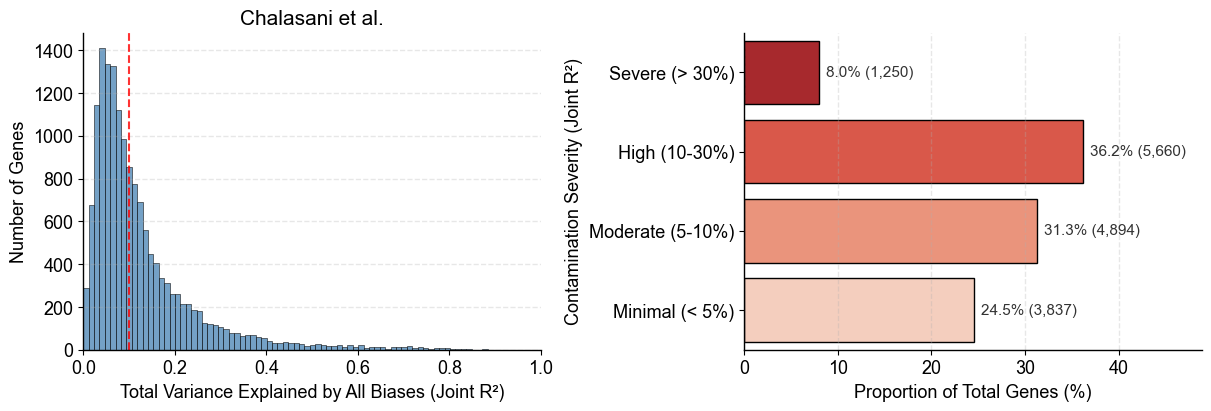


 > Ward Z et al.  (n=340)

--- [Ward Z et al.] Vectorized Gene-wise Partial RDA ---


[Ward Z et al.] Valid samples : 340
[Ward Z et al.] Genes analyzed (≥10% expressed) : 16,290
[Ward Z et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9424   0.3094                14917     > 10%
                Unique: log(Total Reads)  0.1610   0.0112                  683      > 5%
               Unique: Spliced Reads (%)  0.1450   0.0081                  269      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1761   0.0101                  595      > 5%
                   Unique: rRNA Fraction  0.1543   0.0117                  677      > 5%
       Unique: RNA Degradation (3' Bias)  0.1292   0.0075                  276      > 5%
                  Unique: Platelet Score  0.2565   0.0155                 1287      > 5%
                         Unique: GC Bias  0.1623   0.0098                  485      > 5%
                Unique: Gene Length Bias  0.1694   0.0092                  492      > 5%
                            Unique: NG80  0.2056   0.0117  

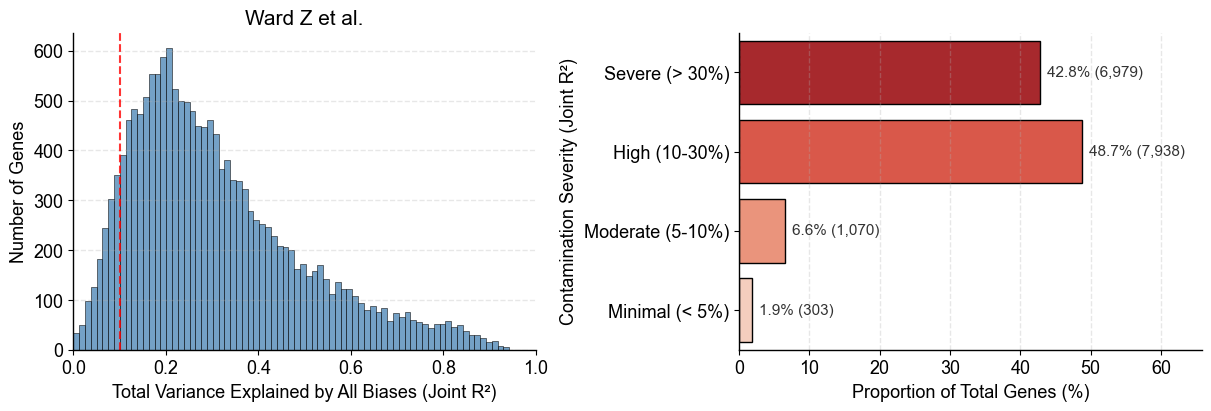


 > Toden et al.  (n=331)

--- [Toden et al.] Vectorized Gene-wise Partial RDA ---


[Toden et al.] Valid samples : 331
[Toden et al.] Genes analyzed (≥10% expressed) : 18,338
[Toden et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9281   0.2516                13524     > 10%
                Unique: log(Total Reads)  0.0991   0.0044                   40      > 5%
               Unique: Spliced Reads (%)  0.1307   0.0119                  854      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1800   0.0075                  328      > 5%
                   Unique: rRNA Fraction  0.0450   0.0022                    0      > 5%
       Unique: RNA Degradation (3' Bias)  0.2330   0.0145                 1093      > 5%
                  Unique: Platelet Score  0.3560   0.0143                 1171      > 5%
                         Unique: GC Bias  0.1988   0.0085                  514      > 5%
                Unique: Gene Length Bias  0.2307   0.0115                  781      > 5%
                            Unique: NG80  0.1643   0.0029  

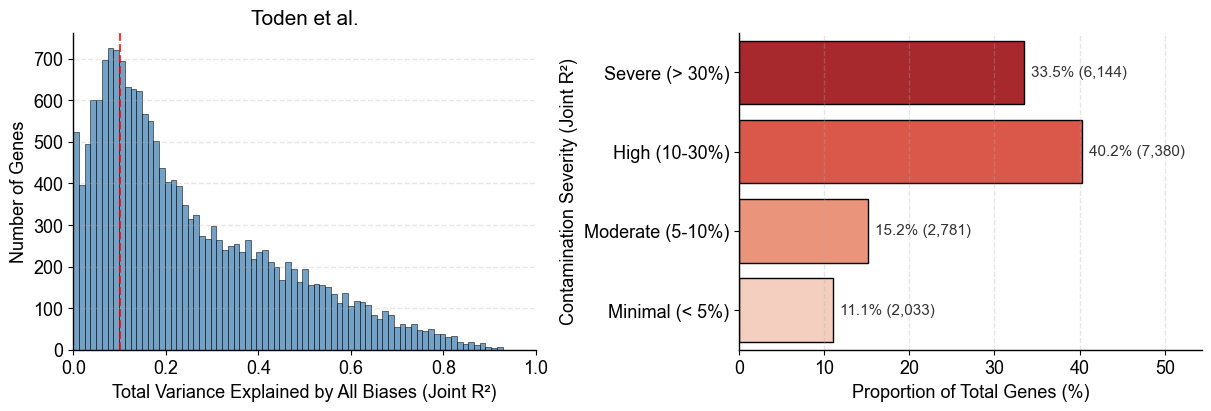


 > Moore et al.  (n=277)

--- [Moore et al.] Vectorized Gene-wise Partial RDA ---


[Moore et al.] Valid samples : 277
[Moore et al.] Genes analyzed (≥10% expressed) : 15,024
[Moore et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.8967   0.2054                11847     > 10%
                Unique: log(Total Reads)  0.0819   0.0032                   10      > 5%
               Unique: Spliced Reads (%)  0.1114   0.0032                   48      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1921   0.0057                  253      > 5%
                   Unique: rRNA Fraction  0.1128   0.0035                   30      > 5%
       Unique: RNA Degradation (3' Bias)  0.1538   0.0042                   78      > 5%
                  Unique: Platelet Score  0.3987   0.0123                  928      > 5%
                         Unique: GC Bias  0.1832   0.0046                   54      > 5%
                Unique: Gene Length Bias  0.2924   0.0141                 1100      > 5%
                            Unique: NG80  0.1269   0.0026  

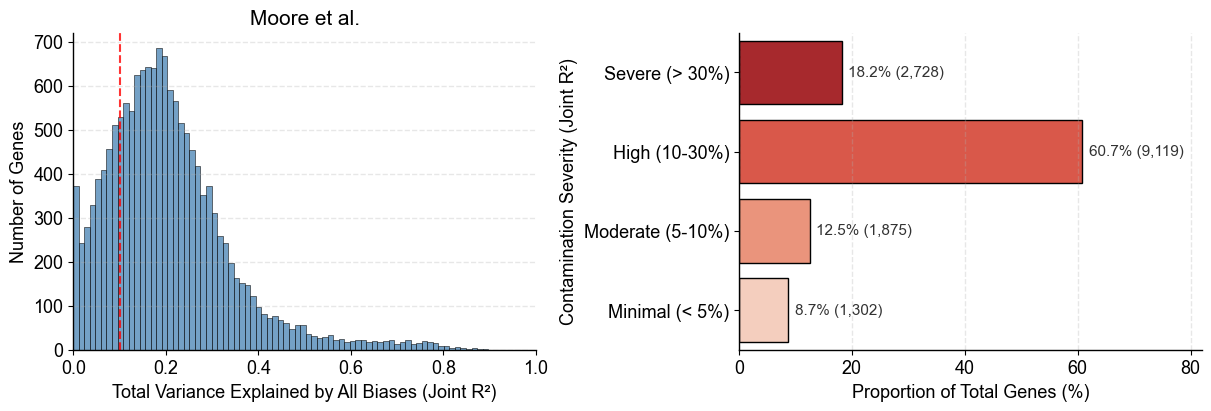


 > Moufarrej et al.  (n=256)

--- [Moufarrej et al.] Vectorized Gene-wise Partial RDA ---


[Moufarrej et al.] Valid samples : 256
[Moufarrej et al.] Genes analyzed (≥10% expressed) : 15,816
[Moufarrej et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9109   0.2492                12160     > 10%
                Unique: log(Total Reads)  0.1238   0.0039                   38      > 5%
               Unique: Spliced Reads (%)  0.0780   0.0030                   14      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1126   0.0051                  167      > 5%
                   Unique: rRNA Fraction  0.1104   0.0031                   15      > 5%
       Unique: RNA Degradation (3' Bias)  0.1274   0.0046                  111      > 5%
                  Unique: Platelet Score  0.1697   0.0062                  324      > 5%
                         Unique: GC Bias  0.1829   0.0079                  429      > 5%
                Unique: Gene Length Bias  0.0961   0.0049                   84      > 5%
                            Unique: NG80  0.1017   0.0049  

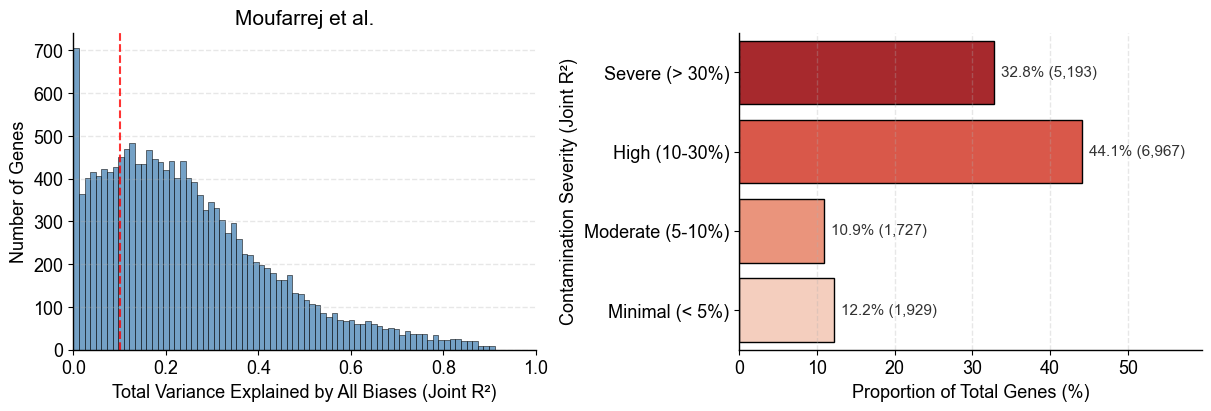


 > Chang et al.  (n=205)

--- [Chang et al.] Vectorized Gene-wise Partial RDA ---


[Chang et al.] Valid samples : 205
[Chang et al.] Genes analyzed (≥10% expressed) : 17,121
[Chang et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9612   0.2475                12398     > 10%
                Unique: log(Total Reads)  0.1473   0.0071                  362      > 5%
               Unique: Spliced Reads (%)  0.1157   0.0044                   90      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.1353   0.0043                  107      > 5%
                   Unique: rRNA Fraction  0.0890   0.0049                   88      > 5%
       Unique: RNA Degradation (3' Bias)  0.1367   0.0047                  151      > 5%
                  Unique: Platelet Score  0.2088   0.0090                  765      > 5%
                         Unique: GC Bias  0.2593   0.0103                  755      > 5%
                Unique: Gene Length Bias  0.1252   0.0050                  170      > 5%
                            Unique: NG80  0.0929   0.0038  

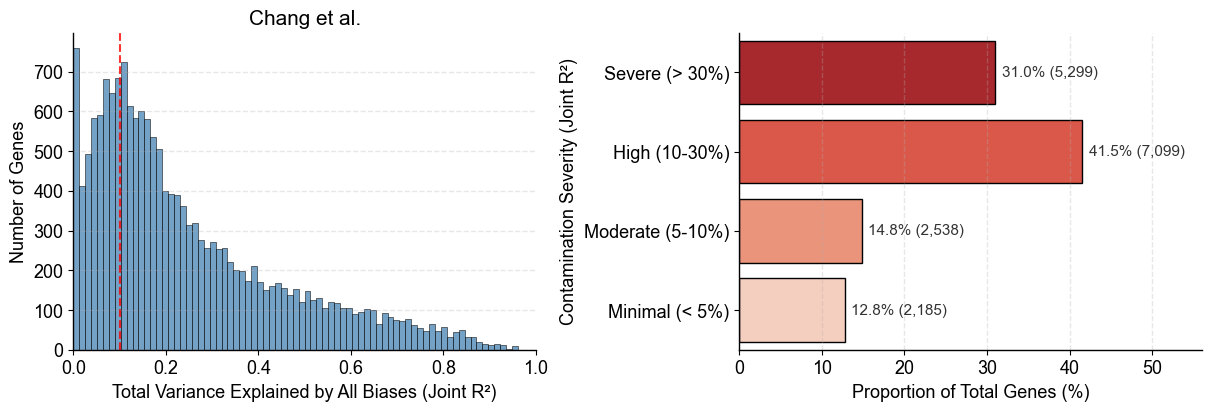


 > Chen et al.  (n=176)

--- [Chen et al.] Vectorized Gene-wise Partial RDA ---


[Chen et al.] Valid samples : 176
[Chen et al.] Genes analyzed (≥10% expressed) : 17,732
[Chen et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9199   0.4763                17303     > 10%
                Unique: log(Total Reads)  0.2643   0.0085                  296      > 5%
               Unique: Spliced Reads (%)  0.2726   0.0086                  480      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.3133   0.0174                 1839      > 5%
                   Unique: rRNA Fraction  0.2583   0.0108                  782      > 5%
       Unique: RNA Degradation (3' Bias)  0.2855   0.0078                  331      > 5%
                  Unique: Platelet Score  0.4388   0.0225                 2347      > 5%
                         Unique: GC Bias  0.2696   0.0100                  670 

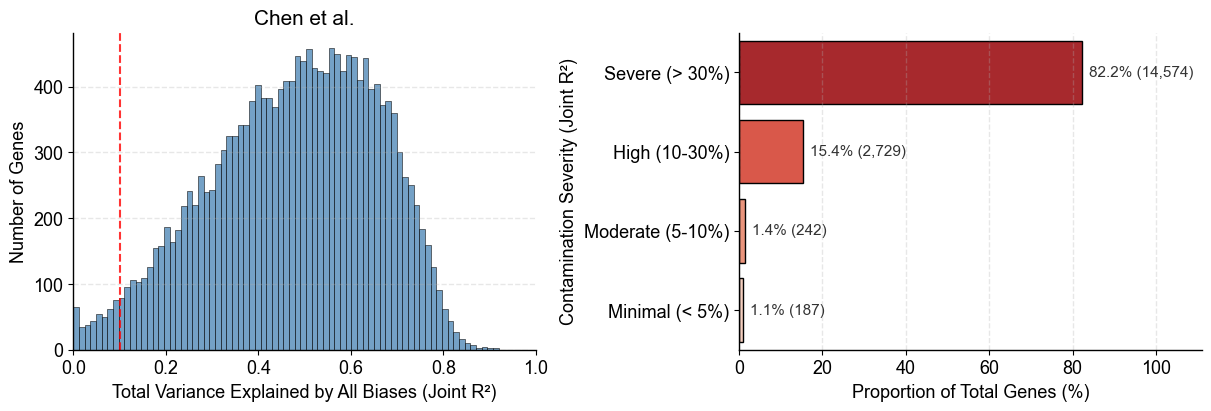


 > Gardella et al.  (n=163)

--- [Gardella et al.] Vectorized Gene-wise Partial RDA ---
[Gardella et al.] Valid samples : 163
[Gardella et al.] Genes analyzed (≥10% expressed) : 16,131
[Gardella et al.] Computing multivariate R² via orthogonal projection...


 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9458   0.4079                13306     > 10%
                Unique: log(Total Reads)  0.1205   0.0055                  174      > 5%
               Unique: Spliced Reads (%)  0.2544   0.0115                  962      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.2257   0.0133                 1049      > 5%
                   Unique: rRNA Fraction  0.1683   0.0097                  584      > 5%
       Unique: RNA Degradation (3' Bias)  0.4478   0.0181                 1531      > 5%
                  Unique: Platelet Score  0.3771   0.0157                 1346      > 5%
                         Unique: GC Bias  0.4099   0.0142                 1164      > 5%
                Unique: Gene Length Bias  0.1730   0.0116                  746      > 5%
                            Unique: NG80  0.1323   0.0078  

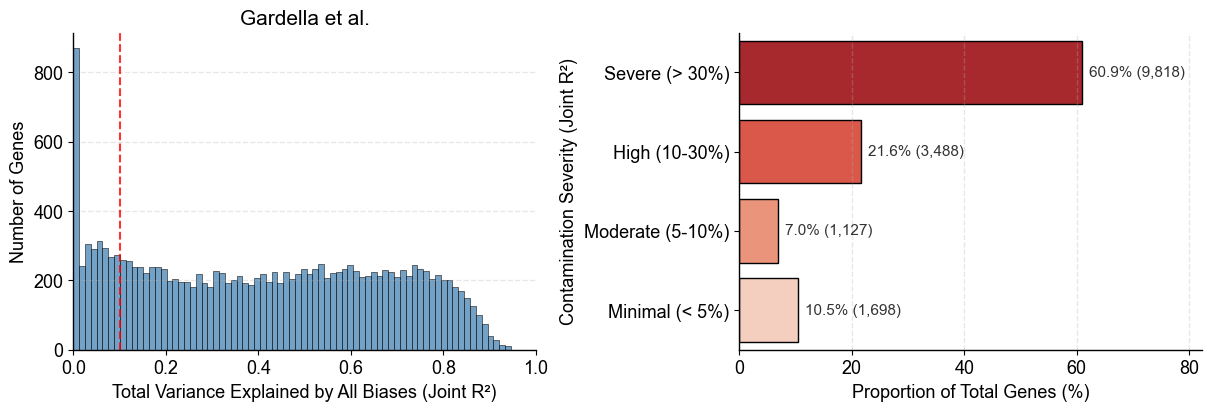


 > Roskams-Hieter B et al.  (n=88)

--- [Roskams-Hieter B et al.] Vectorized Gene-wise Partial RDA ---


[Roskams-Hieter B et al.] Valid samples : 88
[Roskams-Hieter B et al.] Genes analyzed (≥10% expressed) : 17,504
[Roskams-Hieter B et al.] Computing multivariate R² via orthogonal projection...
 [Summary] Gene-level Contamination by Confounders
                      Variance_Component  Max_R2  Mean_R2  Genes_Highly_Biased Threshold
          ALL_BIASES_COMBINED (Joint R²)  0.9312   0.3364                14085     > 10%
                Unique: log(Total Reads)  0.2704   0.0086                  721      > 5%
               Unique: Spliced Reads (%)  0.2176   0.0092                  767      > 5%
Unique: gDNA Contamination (Intron/Exon)  0.4085   0.0136                 1421      > 5%
                   Unique: rRNA Fraction  0.2787   0.0104                  939      > 5%
       Unique: RNA Degradation (3' Bias)  0.3798   0.0113                 1085      > 5%
                  Unique: Platelet Score  0.3504   0.0177                 1860      > 5%
                         Unique: GC Bias  0.

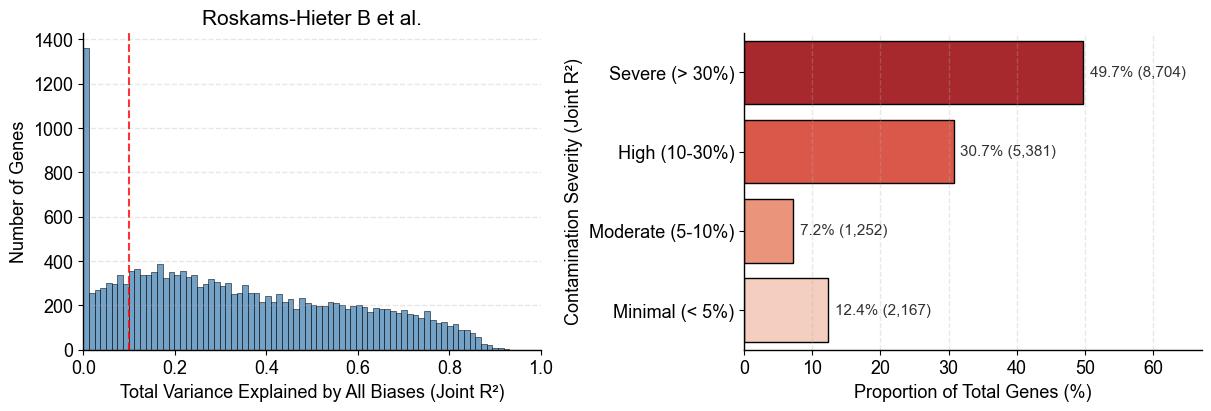

In [8]:
from analysis.plot_gene_bias import plot_gene_wise_bias_summary

study_bias_metrics = combined_metrics + ["Phenotype_Processed"]
MIN_SAMPLES = 30
all_study_summaries = {}
for study in pipeline_rda.valid_studies:
    adata_study = adata_rda[adata_rda.obs["Author"] == study]
    n_samples = len(adata_study)
    if n_samples < MIN_SAMPLES:
        print(f"[Skip] {study}: {n_samples} (< {MIN_SAMPLES})")
        continue

    print(f"\n{'='*60}\n > {study}  (n={n_samples})\n{'='*60}")
    df_detail, df_summary = compute_gene_wise_bias_rda(
        adata_study,
        bias_metrics=study_bias_metrics,
        target_labels=None,
        group_name=study,
        layer="CPM_log1p",
        min_expressed_frac=0.1,
    )
    
    df_summary["Pct_Highly_Biased"] = (df_summary["Genes_Highly_Biased"] / len(df_detail)) * 100
    all_study_summaries[study] = {"detail": df_detail, "summary": df_summary}
    slug = study.replace(" ", "_").replace(".", "_")
    save_dir = f"./Analysis_Results/GeneBiasHC/"
    os.makedirs(save_dir, exist_ok=True)
    plot_gene_wise_bias_summary(
        df_detail,
        group_name=study,
        save_path=None,  # was f"{save_dir}/{slug}_gene_wise_bias_rda_summary.png"
    )